In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


I need to batch activation patch the residual stream over 20 prompts. I think what makes sense is to start with a small model so things will move fast. And all the code should be portable over to a larger qwen.

In [13]:
from nnsight import LanguageModel

model = LanguageModel("Qwen/Qwen3-0.6B")

tokenizer = model.tokenizer

In [14]:
PROMPT_TEMPLATE = """A ball rolls by. Q: What is the second word in the previous sentence? A: ball
Pizza is the best. Q: What is the first word in the previous sentence? A: Pizza
{}. Q: What is the {} word in the previous sentence? Answer in one word only! A:"""
OPTIONS = ["first", "second", "third"]

In [15]:
clean_sentence = 'An artist Jane paints'
clean_prompt = PROMPT_TEMPLATE.format(clean_sentence, OPTIONS[0])
print("Clean Prompt:", clean_prompt)
clean_target_token_id = model.tokenizer.encode(" An", add_special_tokens=False)

Clean Prompt: A ball rolls by. Q: What is the second word in the previous sentence? A: ball
Pizza is the best. Q: What is the first word in the previous sentence? A: Pizza
An artist Jane paints. Q: What is the first word in the previous sentence? Answer in one word only! A:


So to start I need to figure out how to run batch activation patching. Granted, I gave prompts that are all exactly the same token length and I'm always patching the same token position. So I think gemini with the nnsight docs in its context should be able to translate my existing activation patching code into something workable.
For my own understanding, I'll start with single prompt patching things myself.

In [16]:
clean_activations = []
# Run the model on the clean prompt
with model.trace(clean_prompt):
    # Iterate through all layers
    for l in range(model.config.num_hidden_layers):
        # Get the residual output of the layer
        residual_output = model.model.layers[l].output[0].save()
        # Append to our clean_activations list
        clean_activations.append(residual_output)
    # Get the logit of the clean expected answer 
    clean_target_logits = model.output.logits[0][-1, clean_target_token_id].item().save()

In [17]:
print(f"{clean_target_logits=}")
print(f"{len(clean_activations)=}")

clean_target_logits=17.54659652709961
len(clean_activations)=28


## Corrupt Run

In [18]:
corrupt_sentence = 'The artist Jane paints'
corrupt_prompt = PROMPT_TEMPLATE.format(corrupt_sentence, OPTIONS[0])
print("Corrupt Prompt:", corrupt_prompt)
corrupt_target_token_id = model.tokenizer.encode(" The", add_special_tokens=False)

Corrupt Prompt: A ball rolls by. Q: What is the second word in the previous sentence? A: ball
Pizza is the best. Q: What is the first word in the previous sentence? A: Pizza
The artist Jane paints. Q: What is the first word in the previous sentence? Answer in one word only! A:


In [19]:
with model.trace(corrupt_prompt):
    # Save the output logits
    logits = model.output.logits.save()

    # Save the logits for predicting the clean_target
    clean_target_logits_corrupt = model.output.logits[0][-1, clean_target_token_id].item().save()

# Show the corrupt prediction and logits
corrupt_target_logits = logits[0][-1, corrupt_target_token_id].item()
corrupt_prediction = logits.argmax(dim=-1)[:, -1]
corrupt_token_prediction = model.tokenizer.decode(corrupt_prediction)
print(f"{corrupt_token_prediction=}")
print(f"{corrupt_target_logits=}")

# show the logits for the clean target on the corrupt run
print(f"{clean_target_logits_corrupt=}")

corrupt_token_prediction=' Artist'
corrupt_target_logits=16.116065979003906
clean_target_logits_corrupt=13.032010078430176


## Baseline Logit Difference

This gives us a score of the difference between the model's confidence in predicting ' An' when we run the clean prompt versus when we run the corrupt prompt.

In [20]:
total_logit_diff = clean_target_logits - clean_target_logits_corrupt
print(f"Baseline logit difference (clean - corrupt): {total_logit_diff}")

Baseline logit difference (clean - corrupt): 4.514586448669434


## Storing Token IDs

The clean input ids will be used for looping through token-by-token. And both will be used later for decoding back into the tokens for the activation plots.

In [21]:
clean_input_ids = model.tokenizer.encode(clean_prompt)
corrupt_input_ids = model.tokenizer.encode(corrupt_prompt)

assert len(clean_input_ids) == len(corrupt_input_ids)

## Patched Run

Run the model on the corrupt input with residual stream activations restored from the clean run.

In [22]:
from tqdm import trange

patched_activations = []

# Loop through the model layers
for l in trange(model.config.num_hidden_layers):

    patch_at_layer = []

    # For each token position
    for t in range(len(clean_input_ids)):

        # We run the model on the corrupt prompt
        with model.trace(corrupt_prompt):

            # Replace the residual stream output with the clean_activations at that token
            model.model.layers[l].output[0][:, t, :] = clean_activations[l][:, t, :]

            # Get the model output logits
            patched_logits = model.output.logits[0].save()

            # Get the logits for the clean target
            patched_target_logits = patched_logits[-1, clean_target_token_id].item().save()

            # Calculate the logit difference
            logit_diff = patched_target_logits - clean_target_logits_corrupt

            # Normalize the logit difference
            if total_logit_diff == 0:
                normalized_score = 0.0
            else:
                normalized_score = logit_diff / total_logit_diff

            normalized_score = normalized_score.save()

        # Print the layer, token, and logit difference
        print(f"L{l}, T{t}, LD={normalized_score}")

        # Append the token to our list of logit differences at the current layer
        patch_at_layer.append(normalized_score)
    
    # Append each layer's logit differences list to our overall list of lists
    patched_activations.append(patch_at_layer)

print(f"\\nPatched activations shape: {len(patched_activations)} layers x {len(patched_activations[0])} tokens")


  0%|          | 0/28 [00:00<?, ?it/s]

L0, T0, LD=0.0
L0, T1, LD=0.0
L0, T2, LD=0.0
L0, T3, LD=0.0
L0, T4, LD=0.0
L0, T5, LD=0.0
L0, T6, LD=0.0
L0, T7, LD=0.0
L0, T8, LD=0.0
L0, T9, LD=0.0
L0, T10, LD=0.0
L0, T11, LD=0.0
L0, T12, LD=0.0
L0, T13, LD=0.0
L0, T14, LD=0.0
L0, T15, LD=0.0
L0, T16, LD=0.0
L0, T17, LD=0.0
L0, T18, LD=0.0
L0, T19, LD=0.0
L0, T20, LD=0.0
L0, T21, LD=0.0
L0, T22, LD=0.0
L0, T23, LD=0.0
L0, T24, LD=0.0
L0, T25, LD=0.0
L0, T26, LD=0.0
L0, T27, LD=0.0
L0, T28, LD=0.0
L0, T29, LD=0.0
L0, T30, LD=0.0
L0, T31, LD=0.0
L0, T32, LD=0.0
L0, T33, LD=0.0
L0, T34, LD=0.0
L0, T35, LD=0.0
L0, T36, LD=0.0
L0, T37, LD=0.0
L0, T38, LD=0.0
L0, T39, LD=0.0
L0, T40, LD=2.7461576501509226e-06
L0, T41, LD=-1.9011860654891002e-06
L0, T42, LD=1.0129876357420446
L0, T43, LD=0.015454741526360895
L0, T44, LD=0.000563807289865601
L0, T45, LD=8.639834453167134e-05
L0, T46, LD=-0.003943271142720559
L0, T47, LD=0.0010175570308289996
L0, T48, LD=-0.0015872791217872331
L0, T49, LD=0.0010293866330142651
L0, T50, LD=-0.0005154326666437

  4%|▎         | 1/28 [00:14<06:20, 14.09s/it]

L0, T66, LD=0.00149306479009744
L1, T0, LD=0.0
L1, T1, LD=0.0
L1, T2, LD=0.0
L1, T3, LD=0.0
L1, T4, LD=0.0
L1, T5, LD=0.0
L1, T6, LD=0.0
L1, T7, LD=0.0
L1, T8, LD=0.0
L1, T9, LD=0.0
L1, T10, LD=0.0
L1, T11, LD=0.0
L1, T12, LD=0.0
L1, T13, LD=0.0
L1, T14, LD=0.0
L1, T15, LD=0.0
L1, T16, LD=0.0
L1, T17, LD=0.0
L1, T18, LD=0.0
L1, T19, LD=0.0
L1, T20, LD=0.0
L1, T21, LD=0.0
L1, T22, LD=0.0
L1, T23, LD=0.0
L1, T24, LD=0.0
L1, T25, LD=0.0
L1, T26, LD=0.0
L1, T27, LD=0.0
L1, T28, LD=0.0
L1, T29, LD=0.0
L1, T30, LD=0.0
L1, T31, LD=0.0
L1, T32, LD=0.0
L1, T33, LD=0.0
L1, T34, LD=0.0
L1, T35, LD=0.0
L1, T36, LD=0.0
L1, T37, LD=0.0
L1, T38, LD=0.0
L1, T39, LD=0.0
L1, T40, LD=1.9011860654891002e-06
L1, T41, LD=-1.9011860654891002e-06
L1, T42, LD=0.9618816418727358
L1, T43, LD=0.07217578281864354
L1, T44, LD=0.0020433525346084517
L1, T45, LD=0.0056175823377279605
L1, T46, LD=0.0015517903152314366
L1, T47, LD=0.0003356649620069089
L1, T48, LD=0.00516763496889554
L1, T49, LD=0.0004184721773037675
L1

  7%|▋         | 2/28 [00:26<05:44, 13.24s/it]

...

L25, T66, LD=0.9425199629817949
L26, T0, LD=0.0
L26, T1, LD=0.0
L26, T2, LD=0.0
L26, T3, LD=0.0
L26, T4, LD=0.0
L26, T5, LD=0.0
L26, T6, LD=0.0
L26, T7, LD=0.0
L26, T8, LD=0.0
L26, T9, LD=0.0
L26, T10, LD=0.0
L26, T11, LD=0.0
L26, T12, LD=0.0
L26, T13, LD=0.0
L26, T14, LD=0.0
L26, T15, LD=0.0
L26, T16, LD=0.0
L26, T17, LD=0.0
L26, T18, LD=0.0
L26, T19, LD=0.0
L26, T20, LD=0.0
L26, T21, LD=0.0
L26, T22, LD=0.0
L26, T23, LD=0.0
L26, T24, LD=0.0
L26, T25, LD=0.0
L26, T26, LD=0.0
L26, T27, LD=0.0
L26, T28, LD=0.0
L26, T29, LD=0.0
L26, T30, LD=0.0
L26, T31, LD=0.0
L26, T32, LD=0.0
L26, T33, LD=0.0
L26, T34, LD=0.0
L26, T35, LD=0.0
L26, T36, LD=0.0
L26, T37, LD=0.0
L26, T38, LD=0.0
L26, T39, LD=0.0
L26, T40, LD=6.337286884963668e-07
L26, T41, LD=6.337286884963668e-07
L26, T42, LD=-0.0003276377319526216
L26, T43, LD=-0.0007188595756510454
L26, T44, LD=-0.001063185496400738
L26, T45, LD=-1.3730788250754612e-05
L26, T46, LD=7.815987158121856e-06
L26, T47, LD=2.7461576501509226e-06
L26, T48, LD=

 96%|█████████▋| 27/28 [04:33<00:09,  9.81s/it]

L26, T66, LD=1.0018741469747798
L27, T0, LD=0.0
L27, T1, LD=0.0
L27, T2, LD=0.0
L27, T3, LD=0.0
L27, T4, LD=0.0
L27, T5, LD=0.0
L27, T6, LD=0.0
L27, T7, LD=0.0
L27, T8, LD=0.0
L27, T9, LD=0.0
L27, T10, LD=0.0
L27, T11, LD=0.0
L27, T12, LD=0.0
L27, T13, LD=0.0
L27, T14, LD=0.0
L27, T15, LD=0.0
L27, T16, LD=0.0
L27, T17, LD=0.0
L27, T18, LD=0.0
L27, T19, LD=0.0
L27, T20, LD=0.0
L27, T21, LD=0.0
L27, T22, LD=0.0
L27, T23, LD=0.0
L27, T24, LD=0.0
L27, T25, LD=0.0
L27, T26, LD=0.0
L27, T27, LD=0.0
L27, T28, LD=0.0
L27, T29, LD=0.0
L27, T30, LD=0.0
L27, T31, LD=0.0
L27, T32, LD=0.0
L27, T33, LD=0.0
L27, T34, LD=0.0
L27, T35, LD=0.0
L27, T36, LD=0.0
L27, T37, LD=0.0
L27, T38, LD=0.0
L27, T39, LD=0.0
L27, T40, LD=0.0
L27, T41, LD=0.0
L27, T42, LD=0.0
L27, T43, LD=0.0
L27, T44, LD=0.0
L27, T45, LD=0.0
L27, T46, LD=0.0
L27, T47, LD=0.0
L27, T48, LD=0.0
L27, T49, LD=0.0
L27, T50, LD=0.0
L27, T51, LD=0.0
L27, T52, LD=0.0
L27, T53, LD=0.0
L27, T54, LD=0.0
L27, T55, LD=0.0
L27, T56, LD=0.0
L27, T57,

100%|██████████| 28/28 [04:42<00:00, 10.10s/it]

L27, T65, LD=0.0
L27, T66, LD=1.0
\nPatched activations shape: 28 layers x 67 tokens


In [23]:
FEW_SHOT_EXAMPLES = """A ball rolls by. Q: What is the second word in the previous sentence? A: ball
Pizza is the best. Q: What is the first word in the previous sentence? A: Pizza"""

In [24]:
FSE_TOKENS = [tok.replace("Ġ", " ").replace("Ċ", "\n") for tok in model.tokenizer.tokenize(FEW_SHOT_EXAMPLES)]

Scores shape after transpose: (67, 28)
Original scores shape: (67, 28)
Collapsed scores shape: (27, 28)
Number of token labels: 27
Data range: min=-0.0111, max=1.0130


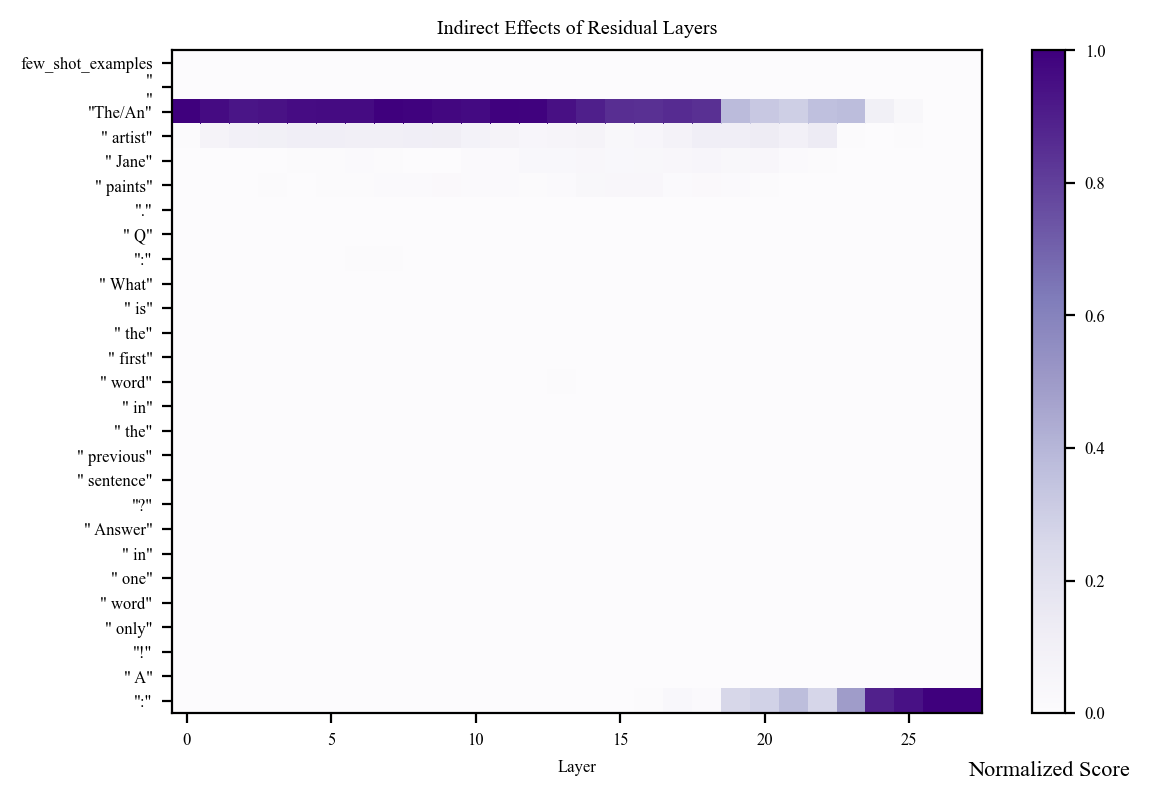

Final data shape: (27, 28)
Number of tokens: 27


In [30]:
import matplotlib.pyplot as plt
import numpy as np

# Create a 2D array: layers as rows, tokens as columns, then transpose
scores = np.array(patched_activations).T  # Transpose so tokens are rows, layers are columns
print(f"Scores shape after transpose: {scores.shape}")

# Decode tokens to actual text
corrupt_tokens = [model.tokenizer.decode([token_id]) for token_id in corrupt_input_ids]
clean_tokens = [model.tokenizer.decode([token_id]) for token_id in clean_input_ids]

# Determine how many tokens belong to few-shot examples
num_fse_tokens = len(FSE_TOKENS)

# Aggregate few-shot example scores (using mean, but could use max, median, etc.)
fse_aggregated = scores[:num_fse_tokens].mean(axis=0, keepdims=True)  # Shape: (1, num_layers)

# Get the remaining scores
remaining_scores = scores[num_fse_tokens:]

# Combine: one row for few-shot examples, then the rest
collapsed_scores = np.vstack([fse_aggregated, remaining_scores])

print(f"Original scores shape: {scores.shape}")
print(f"Collapsed scores shape: {collapsed_scores.shape}")

# Create token labels (skipping few-shot example tokens)
tokens = ["few_shot_examples"]
for idx, (corrupt_tok, clean_tok) in enumerate(zip(corrupt_tokens, clean_tokens)):
    if idx < num_fse_tokens:
        continue
    
    if corrupt_tok != clean_tok:
        tokens.append(f'"{corrupt_tok}/{clean_tok}"')
    else:
        tokens.append(f'"{clean_tok}"')

print(f"Number of token labels: {len(tokens)}")
print(f"Data range: min={collapsed_scores.min():.4f}, max={collapsed_scores.max():.4f}")

plt.rcdefaults()
with plt.rc_context(
    rc={
        "font.family": "Times New Roman",
        "font.size": 6,
    }
):
    # Set figure size
    fig, ax = plt.subplots(
        figsize=(
            6,
            len(tokens) * 0.08 + 1.8
        ),
        dpi=200
    )
    
    # Scale range
    scale_kwargs = {
        "vmin": 0,
        "vmax": 1
    }

    heatmap = ax.pcolor(
        collapsed_scores,  # Use collapsed scores
        cmap="Purples",
        **scale_kwargs,
    )

    ax.invert_yaxis()
    
    # Y-axis: token labels (rows)
    ax.set_yticks([0.5 + i for i in range(len(tokens))])
    ax.set_yticklabels(tokens)
    
    # X-axis: layer labels (columns)
    num_layers = collapsed_scores.shape[1]
    tick_indices = np.arange(0, num_layers, 5)
    ax.set_xticks(tick_indices + 0.5)
    ax.set_xticklabels(tick_indices)

    title = f"Indirect Effects of Residual Layers"
    ax.set_title(title)

    ax.set_xlabel("Layer")

    color_scale = plt.colorbar(heatmap)
    color_scale.ax.set_title(
        f"Normalized Score",
        y=-0.12,
        fontsize=8
    )

    plt.tight_layout()
    plt.show()

print(f"Final data shape: {collapsed_scores.shape}")
print(f"Number of tokens: {len(tokens)}")